In [1]:
from enum import Enum, auto
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import rawpy
from skimage.transform import resize
from sklearn.preprocessing import MinMaxScaler

from Uniforce import Uniforce
from Smcut import Smcut
from data.enums.Algorithm_Over_Clustering import Algorithm_Over_Clustering
from data.options.SpanningTreeOptions import SpanningTreeOptions
from data.options.UniforceOptions import UniforceOptions

Algorithm_Over_Clustering.KmeansPp  # This is just so that auto import clean up won't remove the import of the Algorithms when we save the file and don't use the Algorithms class

<Algorithm_Over_Clustering.KmeansPp: 1>

In [2]:
#%matplotlib notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.metrics.cluster import adjusted_rand_score as ARI
from sklearn.metrics.cluster import normalized_mutual_info_score as NMI
from sklearn.metrics.cluster import adjusted_mutual_info_score as AMI
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

## Generating custom synthetic datasets

In [3]:
def varied_blobs_np(n_samples=2000, n_features=2, n_clusters=3, cluster_std=None):
    SKLEAN_RS = 170

    # create random centers
    centers = np.random.uniform(-15, 15, size=(n_clusters, n_features))

    # if cluster_std not provided, assign default random stds
    if cluster_std is None:
        cluster_std = np.random.uniform(0.2, 1.0, size=n_clusters)

    data, labels = make_blobs(
        n_samples=n_samples,
       # centers = n_clusters,
        centers=centers,
        cluster_std=cluster_std,
        n_features=n_features,
        random_state=SKLEAN_RS
    )

    # scale
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)
    return data, labels


In [6]:
data, labels = varied_blobs_np(n_samples=[10500,10800,16050,22000,15000],n_features=2, n_clusters=5, cluster_std=[0.2, 0.6, 1.0, 0.8, 0.5])#, 0.4,0.2])

In [4]:
data, labels = varied_blobs_np(n_samples=[1050,1800,1650,2200,1500,1600,1700,1560,2100,1230,1300,1450,1800,1567],n_features=2, n_clusters=14, cluster_std=[0.2, 0.6, 1.0, 0.8, 0.5,0.2, 0.6, 1.0, 0.8, 0.5,0.3,0.2,0.4,0.3])#, 0.4,0.2])

In [4]:
data, labels = varied_blobs_np(n_samples=[1050,1800,1650,2200,1500,1600],n_features=2, n_clusters=6, cluster_std=[0.2, 0.6, 1.0, 0.8, 0.5,0.2])#, 0.4,0.2])

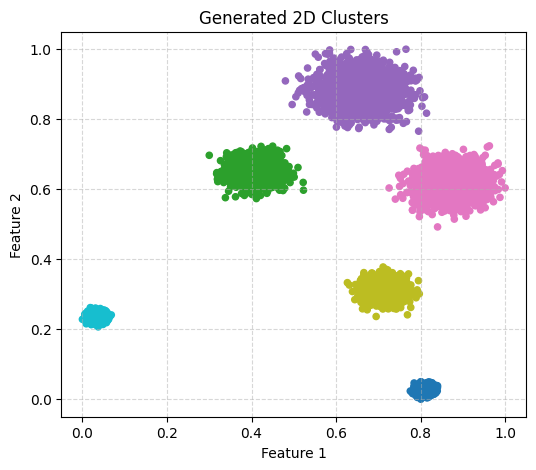

In [5]:
# plot the clusters
plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap="tab10", s=20)
plt.title("Generated 2D Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Running the UniForCE and SMCUT algorithms

In [6]:
options = UniforceOptions(spanning_tree_options=SpanningTreeOptions(alpha=1e-3),
                          algorithm_over_clustering=Algorithm_Over_Clustering.GlobalKMeansPp)
options.number_of_clusters = 6

In [ ]:
uni1 = Uniforce(options).fit(data)

In [ ]:
final_labels = uni1.labels
estimated_k = uni1.n_clusters
print(f"The algorithm found {estimated_k} clusters.")
ami_score = AMI(labels, final_labels)
print(f"AMI Score: {ami_score}")

In [7]:
print("Running Baseline UniForCE...")
model_base = Uniforce(options=UniforceOptions(number_of_clusters=25))
results_base = model_base.fit(data)
ami_base = AMI(labels, results_base.labels)

print("Running UniForCE Mudpod...")
model_mudpod = Smcut(options=UniforceOptions(number_of_clusters=25))
results_mudpod = model_mudpod.fit(data)
ami_mudpod = AMI(labels, results_mudpod.labels)

print(f"AMI Initial: {ami_base:.4f} | Found {results_base.n_clusters} clusters")
print(f"AMI Mudpod:  {ami_mudpod:.4f} | Found {results_mudpod.n_clusters} clusters")

Running Baseline UniForCE...
Starting Over Clustering (GlobalKMeansPp)...
Solving last 25-means.
Finished Over Clustering.
Starting Minimum Spanning Tree (Kruskal)...
Initializing edges...
Sorting edges...
Reassigning inactive sub clusters...
Recalculating sub cluster centers...
Connecting edges...
Finished Minimum Spanning Tree.
Running UniForCE Mudpod...
Starting Over Clustering (GlobalKMeansPp)...


C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\random_projection.py:408: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (2 < 71).The dimensionality of the problem will not be reduced.
  warnings.warn(
2026-08-21 09:51:58.794 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9197561370873512.
C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\random_projection.py:408: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (2 < 71).The dimensionality of the problem will not be reduced.
  warnings.warn(
2026-08-21 09:51:58.818 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.926440753028277.
C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\random_projection.py:408: DataDimensionalityWarning: The number of components is 

Solving last 25-means.
Finished Over Clustering.
Starting Mudpod Unimodality Check


C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\random_projection.py:408: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (2 < 71).The dimensionality of the problem will not be reduced.
  warnings.warn(
2026-08-21 09:51:58.875 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9182887142481506.
C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\random_projection.py:408: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (2 < 71).The dimensionality of the problem will not be reduced.
  warnings.warn(
2026-08-21 09:51:58.899 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9270739296338155.
C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\random_projection.py:408: DataDimensionalityWarning: The number of components is

Finished Mudpod Unimodality Check
Total unimodal subclusters after mudpod test: 26
Starting Minimum Spanning Tree (Kruskal)...
Initializing edges...
Sorting edges...
Reassigning inactive sub clusters...
Recalculating sub cluster centers...
Connecting edges...
Finished Minimum Spanning Tree.
AMI Initial: 1.0000 | Found 6 clusters
AMI Mudpod:  1.0000 | Found 6 clusters


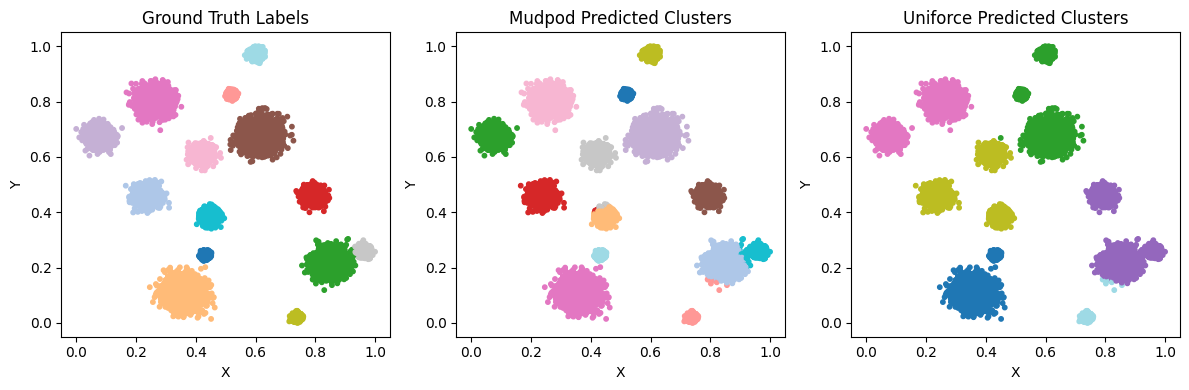

In [18]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(12,4))#12, 4))  # 1 row, 3 columns

# Left: UniForCE
#axes[0].scatter(data[:, 0], data[:, 1], c=uniforce.labels_, cmap="tab20", s=10)
#axes[0].set_title("UniForCE Predicted Clusters")
#axes[0].set_xlabel("X")
#axes[0].set_ylabel("Y")

# Middle: Ground truth
axes[0].scatter(data[:, 0], data[:, 1], c=labels, cmap="tab20", s=10)
axes[0].set_title("Ground Truth Labels")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# Right: Mudpod
axes[1].scatter(data[:, 0], data[:, 1], c=results_mudpod.labels, cmap="tab20", s=10)
axes[1].set_title("Mudpod Predicted Clusters")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

axes[2].scatter(data[:, 0], data[:, 1], c=results_base.labels, cmap="tab20", s=10)
axes[2].set_title("Uniforce Predicted Clusters")
axes[2].set_xlabel("X")
axes[2].set_ylabel("Y")

plt.tight_layout()
#plt.show()


## Running step by step the 'overclustering' step of SMCUT algorithm

In [3]:
from overclustering.OverClusteringUtils import check_clusters_with_mudpod, over_clustering

**Defining the options variable**

In [5]:
options=UniforceOptions(number_of_clusters=50)

In [7]:
#data, labels = get_Pendigits_np()
#data, labels = get_TCGA_np()
data, labels = get_waveform_np()
#data, labels = get_mice_protein_np()
#data, labels = get_EMNIST_MNIST_embeddings_np()
#data, labels = get_EMNIST_BD_embeddings_np() # Balanced Digits
#data, labels = get_EMNIST_BL_embeddings_np() # Balanced Letters
#data, labels = get_optdigits_np()
#data, labels = get_Isolet_np()

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [7]:
len(np.unique(labels))

10

In [9]:
overClusteringResult = over_clustering(data= data, algorithm = options.algorithm_over_clustering, number_of_clusters= options.number_of_clusters)
print("Finished Overclustering")
print("initial subclusters :",options.number_of_clusters)

mudpod_result = check_clusters_with_mudpod(
            data = data,
            initial_result = overClusteringResult,
            mudpod_options = options.mudpod_options,
            #alpha = alpha,
            min_size = 25
        )
print("Finished Mudpod Unimodality Check")
new_k = len(over_clustering_result.cluster_centers)
print("Total unimodal subclusters after mudpod test:", new_k)

Solving last 50-means.


2026-03-05 09:03:14.907 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.987951675514062.
2026-03-05 09:03:14.928 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9513307864841731.
2026-03-05 09:03:14.931 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.6659038970176303.
2026-03-05 09:03:14.947 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9913007839968073.
2026-03-05 09:03:14.950 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.8115665801597862.
2026-03-05 09:03:14.966 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9926387751116147.
2026-03-05 09:03:14.968 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9940870819857978.
2026-03-05 09:03:14.984 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9803093308018973.
2026-03-05 09:03:14.997 | DEBUG    | mudpod.unimodality:test:44 - The uni

Finished Overclustering
initial subclusters : 50


2026-03-05 09:03:15.104 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9906615034729679.
2026-03-05 09:03:15.104 | DEBUG    | mudpod.unimodality:estimate:92 - The result of the Monte Carlo simulations is: [True, True, True, True, True, True, True, True, True, True]
2026-03-05 09:03:15.119 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.8285095786133474.
2026-03-05 09:03:15.129 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.27435148169395396.
2026-03-05 09:03:15.133 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.943354529323844.
2026-03-05 09:03:15.133 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9927781871352575.
2026-03-05 09:03:15.149 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9760904311652541.
2026-03-05 09:03:15.150 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.5063170245371222.
2026-03-05 

Finished Mudpod Unimodality Check
Total unimodal subclusters after mudpod test: 51


## Functions For the Datasets

In [6]:
def get_TCGA_np():
    df_data = pd.read_csv('../../TCGA/data.csv', index_col = 0)
    df_labels = pd.read_csv('../../TCGA/labels.csv', index_col = 0)

    data = np.array(df_data)
    labels = np.squeeze(np.array(df_labels))

    data = MinMaxScaler().fit_transform(data)
    labels = LabelEncoder().fit_transform(labels)

    return data, labels

def get_waveform_np():
    df_data = pd.read_csv('../../waveform-v1/data.csv', header = None)
    df_labels = pd.read_csv('../../waveform-v1/labels.csv', header = None)

    data = np.array(df_data)
    labels = df_labels.to_numpy()
    data = MinMaxScaler().fit_transform(data)
    labels = LabelEncoder().fit_transform(labels)

    return data, labels

def get_Pendigits_np():
    data = np.vstack([
        np.loadtxt("../../Pendigits/pendigits.tra", delimiter=','),
        np.loadtxt("../../Pendigits/pendigits.tes", delimiter=',')
    ])
    pendigits, labels = data[:, :-1], data[:, -1:]

    # Fix pendigits
    pendigits = pendigits.astype("float")
    scaler = MinMaxScaler()
    pendigits = scaler.fit_transform(pendigits)

    # Fix labels
    labels = np.squeeze(labels)
    labels = labels.astype("int")

    return pendigits, labels

def get_EMNIST_MNIST_embeddings_np():
    data = np.load('../../EMNIST_MNIST_embeddings_leaky/data.npy')
    labels = np.load('../../EMNIST_MNIST_embeddings_leaky/labels.npy')
    data = MinMaxScaler().fit_transform(data)
    labels = labels.astype('int')
    return data, labels

def get_EMNIST_BD_embeddings_np():
    data = np.load('../../EMNIST_balanced_digits_leaky/data.npy')
    labels = np.load('../../EMNIST_balanced_digits_leaky/labels.npy')
    data = MinMaxScaler().fit_transform(data)
    labels = labels.astype('int')
    return data, labels

#def get_EMNIST_BL_A_J_embeddings_np():
def get_EMNIST_BL_embeddings_np():
    data = np.load('../../EMNIST_balanced_letters_A-J/data.npy')
    labels = np.load('../../EMNIST_balanced_letters_A-J/labels.npy')
    data = MinMaxScaler().fit_transform(data)
    labels = labels.astype('int')
    return data, labels

def get_optdigits_np():
    train = pd.read_csv('../../Optdigits/optdigits.tra', header=None)
    test = pd.read_csv('../../Optdigits/optdigits.tes', header=None)
    df = pd.concat([train, test], ignore_index=True)
    labels = df[64].to_numpy()
    df.drop(columns=[64], inplace=True)
    data = df.to_numpy()
    data = MinMaxScaler().fit_transform(data)
    return data, labels

def get_Isolet_np():
    df_tr = pd.read_csv('../../Isolet/Train/data', header=None)
    df_ts = pd.read_csv('../../Isolet/Test/data', header=None)
    df = pd.concat((df_tr, df_ts))

    labels = df[df.columns[-1]].to_numpy()
    df.drop(columns=df.columns[-1], inplace=True)
    data = df.to_numpy()
    
    data = MinMaxScaler().fit_transform(data)
    labels = LabelEncoder().fit_transform(labels)
    
    return data, labels

def get_mice_protein_np():
    df = pd.read_excel('../../mice-protein/Data_Cortex_Nuclear.xls', header=0)
    df.drop(columns=['MouseID'], inplace=True)
    df.fillna(value=df.mean(numeric_only=True), inplace=True)
    df = pd.get_dummies(df, columns = ['Genotype', 'Treatment', 'Behavior'])

    labels = df['class'].to_numpy()
    df.drop(columns=['class'], inplace=True)

    data = df.to_numpy()
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    labels = LabelEncoder().fit_transform(labels)
    return data, labels

In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

data_details = {
    1: ("twodiamonds.arff", 18),
    2: ("diamond9.arff", 9),
    3: ("longsquare.arff", 9),
    4: ("ds2c2sc13.arff", 11),
    5: ("zelnik1.arff",11),
    6: ("2dnormals.arff", 13),
    7: ("2sp2glob.arff", 13),
    14: ("aggregation.arff", 12),
    16: ("banana.arff", 7),
    22: ("circle.arff", 20),
    28: ("complex9.arff", 9),
    30: ("cure-t0-2000n-2D.arff", 7),
    31: ("cure-t1-2000n-2D.arff", 7),
    72: ("s-set1.arff", 7),
    83: ("smile3.arff", 10),
    90: ("triangle2.arff", 7),
    91: ("twenty.arff", 8),
    94: ("xclara.arff", 8),
    99: ("zelnik5.arff", 11),
    100: ("atom.arff", 19), # 3d
    101: ("chainlink.arff", 19), # 3d
    102: ("target.arff", 18),
    103: ("jain.arff",11),
}

def get_Complex_2D_v1():
    circles, circles_labels = make_circles(n_samples=5_000, factor=0.9, noise=0.05, random_state=6)
    inner_circle_index = np.where(circles_labels==1)
    data = circles[inner_circle_index]
    labels = circles_labels[inner_circle_index] - 1
    moons, moons_labels = make_moons(n_samples=1_500, noise=0.1, random_state=0)
    upper_moon_index = np.where(moons_labels==0)
    lower_moon_index = np.where(moons_labels==1)
    moons[:,0] -= np.mean(moons[:,0])
    moons[:,1] -= np.mean(moons[:,1])
    moons = moons[:, [1,0]]
    moons[:,0][upper_moon_index] -= 1.05
    moons[:,0][lower_moon_index] += 1.05
    moons[:,1][upper_moon_index] += .5
    moons[:,1][lower_moon_index] -= .5
    moons *= [0.4, 0.43]
    moons_labels = np.full(shape=(moons.shape[0]), fill_value=1)
    data = np.vstack((data, moons))
    labels = np.concatenate((labels, moons_labels))
    centers = [(-0.5, 0.0), (0.5, 0.0), (0.0, -0.625), (0.0, 0.625)]
    cluster_std = [(0.08, 0.08), (0.08, 0.08), (0.1, 0.03), (0.1, 0.03)]
    n_samples = [250, 250, 250, 250]
    blobs, blobs_labels = make_blobs(n_samples=n_samples, centers=centers, cluster_std=cluster_std, random_state=15)
    data = np.vstack((data, blobs))
    labels = np.concatenate((labels, blobs_labels+2))
    centers = [(0, 0)]
    cluster_std = [(0.04, 0.17)]
    center_blob, _ = make_blobs(n_samples=500, centers=centers, cluster_std=cluster_std, random_state=9)
    center_blob_labels = np.full(shape=center_blob.shape[0], fill_value=1)
    data = np.vstack((data, center_blob))
    labels = np.concatenate((labels, center_blob_labels))
    return data, labels

def get_Complex_2D_v2():
    circles, circles_labels = make_circles(n_samples=5_000, factor=0.9, noise=0.05, random_state=0)
    inner_circle_index = np.where(circles_labels==1)
    data = circles[inner_circle_index]
    labels = circles_labels[inner_circle_index] - 1
    moons, moons_labels = make_moons(n_samples=2_000, noise=0.1, random_state=0)
    upper_moon_index = np.where(moons_labels==0)
    lower_moon_index = np.where(moons_labels==1)
    moons[:,0] -= np.mean(moons[:,0])
    moons[:,1] -= np.mean(moons[:,1])
    moons = moons[:, [1,0]]
    moons[:,0][upper_moon_index] += .25
    moons[:,0][lower_moon_index] -= .25
    moons *= [0.6, 0.3]
    data = np.vstack((data, moons))
    labels = np.concatenate((labels, moons_labels+1))
    centers=[(-0.25, 0.15), (0.25, -0.15), (0.25, 0.5), (-0.25, -0.5)]
    blobs, blobs_labels = make_blobs(n_samples=500, centers=centers, cluster_std=0.05, random_state=0)
    data = np.vstack((data, blobs))
    labels = np.concatenate((labels, blobs_labels+3))
    return data, labels

def get_artificial2D(path, skiprows):
    full_path = "./Artificial/" + path
    df = pd.read_csv(full_path, skiprows=skiprows, names=['x', 'y', 'class'])
    labels = df["class"].to_numpy()
    label_enc = LabelEncoder()
    labels = label_enc.fit_transform(labels)
    df.drop(columns=["class"], inplace=True)
    data = df.to_numpy()
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)
    return data, labels

def get_artificial3D(path, skiprows):
    full_path = "./Artificial/" + path
    df = pd.read_csv(full_path, skiprows=skiprows, names=['x', 'y', 'z', 'class'])
    labels = df["class"].to_numpy()
    label_enc = LabelEncoder()
    labels = label_enc.fit_transform(labels)
    df.drop(columns=["class"], inplace=True)
    data = df.to_numpy()
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)
    return data, labels

def load_dataset(dataset_name):
    match dataset_name:
        case 'Complex 2D':
            data, labels = get_Complex_2D_v1()
        case 'Complex 2D v2':
            data, labels = get_Complex_2D_v2()
    return data, labels

## Comparing Uniforce with SMCUT

importing the necessary functions

In [5]:
from overclustering.OverClusteringUtils import check_clusters_with_mudpod, over_clustering
from spanningtree.MinimumSpanningTreeUtils import spanning_tree
from data.results.UniforceResult import UniforceResult
from sklearn.metrics.cluster import normalized_mutual_info_score as NMI
from sklearn.metrics.cluster import adjusted_mutual_info_score as AMI
from data.options.UniforceOptions import MudpodOptions

In [6]:
import warnings
warnings.filterwarnings("ignore")

loading the dataset we want to run

In [7]:
#data, labels = get_Pendigits_np()
#data, labels = get_TCGA_np()
#data, labels = get_waveform_np()
#data, labels = get_mice_protein_np()
data, labels = get_EMNIST_MNIST_embeddings_np()
#data, labels = get_EMNIST_BD_embeddings_np() # Balanced Digits
#data, labels = get_EMNIST_BL_embeddings_np() # Balanced Letters
#data, labels = get_optdigits_np()
#data, labels = get_Isolet_np()

In [31]:
len(np.unique(labels))

26

In [8]:
data.shape

(70000, 10)

In [16]:
dataset_name = "mice_protein"

Loading a synthetic dataset

In [21]:
data, labels = load_dataset('Complex 2D')
print(f"The dataset has been loaded! Size of data: {data.shape}")
dataset_name = "complex_2D"

The dataset has been loaded! Size of data: (5500, 2)


Loading an artificial dataset

In [18]:
data_id = 1
path, skiprows = data_details[data_id]
dataset_name = path
data, labels = get_artificial2D(path, skiprows)
print(f"The dataset {path} has been loaded! Size of data: {data.shape}")

The dataset twodiamonds.arff has been loaded! Size of data: (800, 2)


In [25]:
data.shape

(1000, 3)

In [26]:
len(np.unique(labels))

2

In [24]:
data_id = 101
path, skiprows = data_details[data_id]
dataset_name = path
data, labels = get_artificial3D(path, skiprows)
print(f"The dataset {path} has been loaded! Size of data: {data.shape}")

The dataset chainlink.arff has been loaded! Size of data: (1000, 3)


In [480]:
data, labels = get_Complex_2D_v2()
dataset_name = "complex_2D_v2"

In [187]:
np.unique(labels)

array([0, 1, 2, 3, 4, 5], dtype=int64)

Defining the options object

In [326]:
#mudpod_options = MudpodOptions(pv = 0.1)
spanning_tree_optionsObj = SpanningTreeOptions(min_samples_per_sub_cluster=25,majority_n_tests=11,alpha=1e-3)
options=UniforceOptions(number_of_clusters=70,spanning_tree_options=spanning_tree_optionsObj)#, mudpod_options = mudpod_options)

This is where we first run the **over_clustering** function and get the initial subclustering. Then we run the **check_clusters_with_mudpod** function to get the subclustering after the unimodality check at each cluster.

In [327]:
overClusteringResult = over_clustering(data= data, algorithm = options.algorithm_over_clustering, number_of_clusters= options.number_of_clusters)
print("Finished Overclustering")
print("initial subclusters :",options.number_of_clusters)
n_subclusters = options.number_of_clusters
overClustering_labels = np.copy(overClusteringResult.labels)

Solving last 70-means.
Finished Overclustering
initial subclusters : 70


In [328]:
mudpod_result = check_clusters_with_mudpod(
            data = data,
            initial_result = overClusteringResult,
            mudpod_options = options.mudpod_options,
            min_size = 25
        )
print("Finished Mudpod Unimodality Check")
new_k = mudpod_result.cluster_centers.shape[0]

print("Total unimodal subclusters after mudpod test:", new_k)

2026-04-27 13:50:03.459 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.8446750324664964.
2026-04-27 13:50:03.529 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9945883771152252.
2026-04-27 13:50:03.591 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.7708893888756284.
2026-04-27 13:50:03.658 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.7079097079604358.
2026-04-27 13:50:03.720 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.5426920192860958.
2026-04-27 13:50:03.779 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.47095532045059463.
2026-04-27 13:50:03.838 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.9010887000118186.
2026-04-27 13:50:03.895 | DEBUG    | mudpod.unimodality:test:44 - The unimodality statistic is: 0.980945693253602.
2026-04-27 13:50:03.959 | DEBUG    | mudpod.unimodality:test:44 - The un

Finished Mudpod Unimodality Check
Total unimodal subclusters after mudpod test: 70


After that, we run two the versions of the **spanning tree** function. The first version refers to the initial version of uniforce, without the mudpod test. The second version refers to the enhanced version, with the mudpod test.

In [329]:
# initial version
minimumSpanningTreeResult = spanning_tree(
            data=data,
            algorithm=options.algorithm_spanning_tree,
            labels=overClusteringResult.labels,
            cluster_centers=overClusteringResult.cluster_centers,
            number_of_sub_clusters=options.number_of_clusters,
            options=options.spanning_tree_options
        )
uniforce_result = UniforceResult(
            labels=minimumSpanningTreeResult.labels,
            sub_labels=minimumSpanningTreeResult.sub_labels,
            sub_cluster_centers=minimumSpanningTreeResult.sub_cluster_centers,
            adjacency=minimumSpanningTreeResult.adjacency,
            is_active=minimumSpanningTreeResult.is_active,
            clusters=minimumSpanningTreeResult.clusters,
            n_clusters=len(minimumSpanningTreeResult.clusters),
            n_sub_clusters=minimumSpanningTreeResult.sub_cluster_centers.shape[0]
        )
print("Finished with UniForCE")
print("Starting SMCUT")
# mudpord versions
minimumSpanningTreeResult_mudpod = spanning_tree(
            data=data,
            algorithm=options.algorithm_spanning_tree,
            labels=mudpod_result.labels,
            cluster_centers=mudpod_result.cluster_centers,
            number_of_sub_clusters= mudpod_result.cluster_centers.shape[0], #self._options.number_of_clusters,
            options=options.spanning_tree_options
        )

uniforce_mudpod_result = UniforceResult(
            labels=minimumSpanningTreeResult_mudpod.labels,
            sub_labels=minimumSpanningTreeResult_mudpod.sub_labels,
            sub_cluster_centers=minimumSpanningTreeResult_mudpod.sub_cluster_centers,
            adjacency=minimumSpanningTreeResult_mudpod.adjacency,
            is_active=minimumSpanningTreeResult_mudpod.is_active,
            clusters=minimumSpanningTreeResult_mudpod.clusters,
            n_clusters=len(minimumSpanningTreeResult_mudpod.clusters),
            n_sub_clusters=minimumSpanningTreeResult_mudpod.sub_cluster_centers.shape[0]
        )
print("Finished SMCUT")

Initializing edges...
Sorting edges...
Reassigning inactive sub clusters...
Recalculating sub cluster centers...
Connecting edges...
Finished with UniForCE
Starting UniForCE_Mudpod
Initializing edges...
Sorting edges...
Reassigning inactive sub clusters...
Recalculating sub cluster centers...
Connecting edges...
Finished UniForCE_Mudpod


In [331]:
ami_uniforce = AMI(labels, uniforce_result.labels)
ami_uniforce_mudpod = AMI(labels, uniforce_mudpod_result.labels)
algo_comparison_ami = AMI(uniforce_result.labels,uniforce_mudpod_result.labels)

print(f"AMI between the two versions: {algo_comparison_ami: .4f}")
print(f"AMI Initial: {ami_uniforce:.4f} | Found {uniforce_result.n_clusters} clusters")
print(f"AMI with Mudpod:  {ami_uniforce_mudpod:.4f} | Found {uniforce_mudpod_result.n_clusters} clusters")

nmi_uniforce = NMI(labels, uniforce_result.labels)
nmi_uniforce_mudpod = NMI(labels, uniforce_mudpod_result.labels)
algo_comparison_nmi = NMI(uniforce_result.labels,uniforce_mudpod_result.labels)

print(f"NMI between the two versions: {algo_comparison_nmi: .4f}")
print(f"NMI Initial: {nmi_uniforce:.4f}")
print(f"NMI with Mudpod:  {nmi_uniforce_mudpod:.4f}")

AMI between the two versions:  0.9458
AMI Initial: 0.9689 | Found 5 clusters
AMI with Mudpod:  0.9192 | Found 6 clusters
NMI between the two versions:  0.9462
NMI Initial: 0.9691
NMI with Mudpod:  0.9199


## Creating the Plots

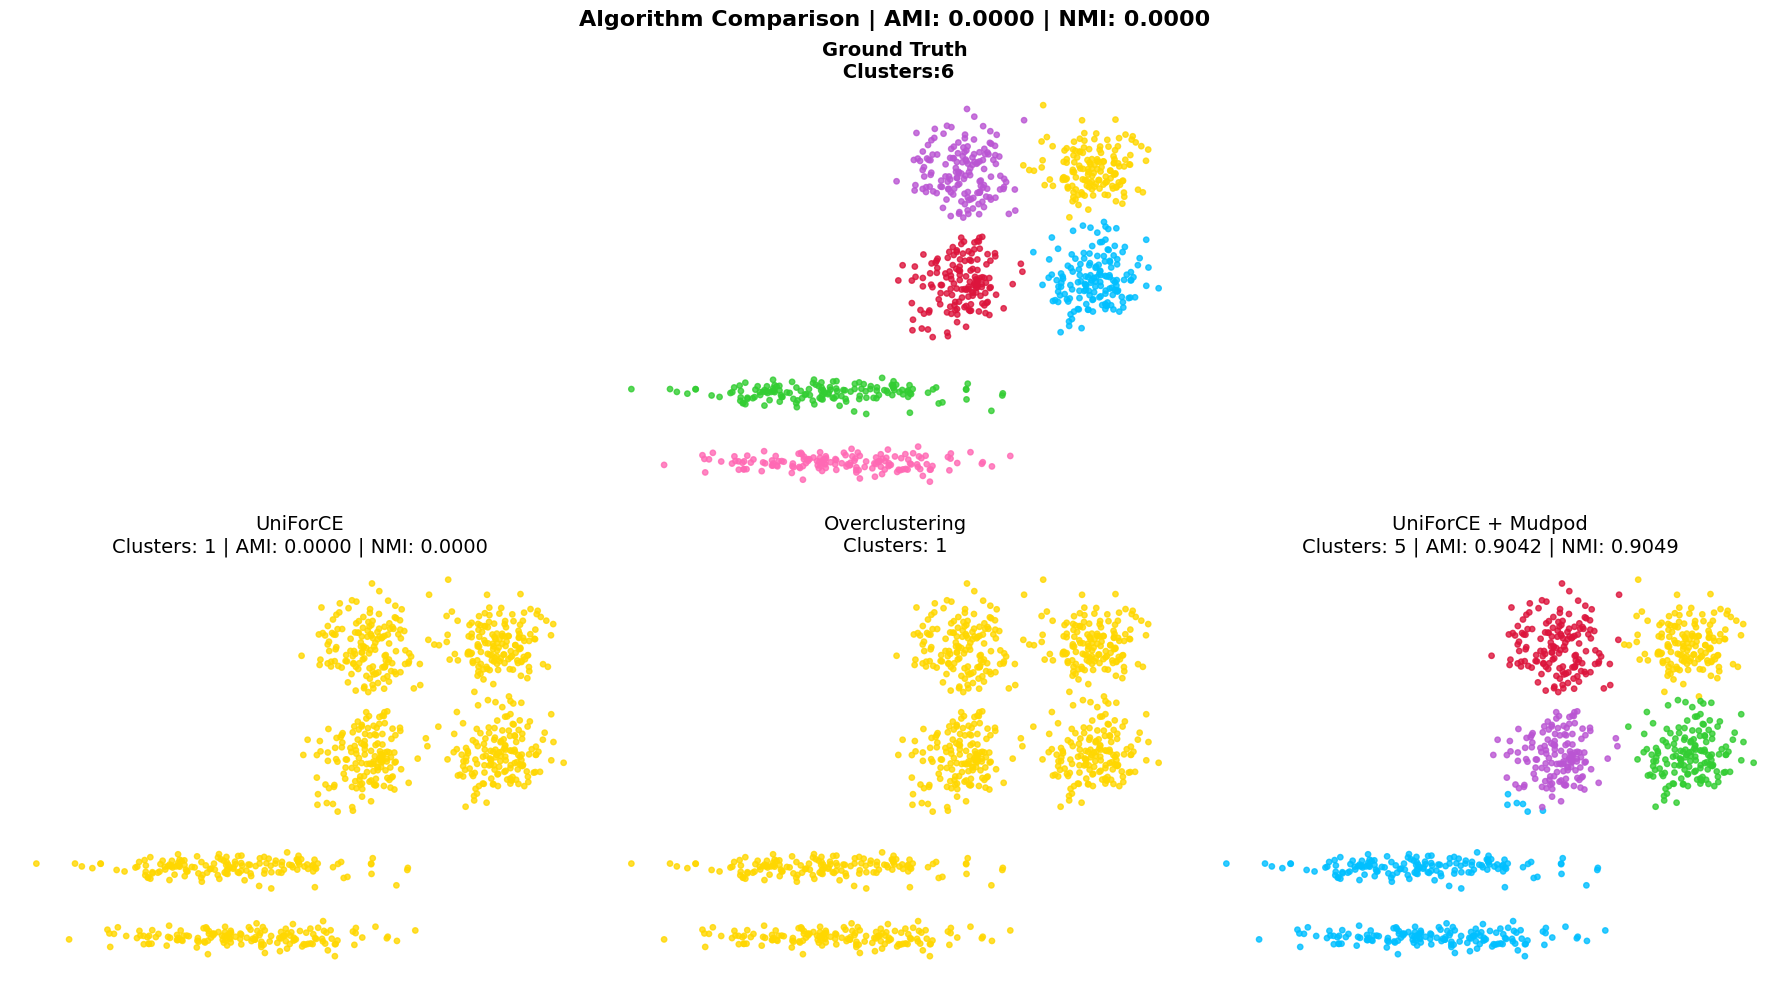

In [229]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np




color_list = list(mcolors.CSS4_COLORS.keys()) + list(mcolors.XKCD_COLORS.keys())
np.random.seed(42) 
np.random.shuffle(color_list)
color_list = ['gold', 'deepskyblue', 'mediumorchid', 'crimson', 'limegreen', 'hotpink', 'royalblue', 'salmon'] + color_list


fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 6) 

# 1. ground truth 
ax_gt = fig.add_subplot(gs[0, 2:4])
ax_gt.scatter(data[:, 0], data[:, 1], c=[color_list[l % len(color_list)] for l in labels], s=15, alpha=0.8)
ax_gt.set_title(f"Ground Truth\n Clusters:{len(np.unique(labels))}", fontsize=14, fontweight='bold')
ax_gt.axis('off')

# 2. UniForCE 
ax_uf = fig.add_subplot(gs[1, 0:2])
ax_uf.scatter(data[:, 0], data[:, 1], c=[color_list[l % len(color_list)] for l in uniforce_result.labels], s=15, alpha=0.8)
ax_uf.set_title(f"UniForCE\nClusters: {uniforce_result.n_clusters} | AMI: {ami_uniforce:.4f} | NMI: {nmi_uniforce:.4f}", fontsize=14)
ax_uf.axis('off')

# 3. overclustering 
ax_over = fig.add_subplot(gs[1, 2:4])
ax_over.scatter(data[:, 0], data[:, 1], c=[color_list[l % len(color_list)] for l in overClustering_labels], s=15, alpha=0.8)
ax_over.set_title(f"Overclustering\nClusters: {len(np.unique(overClustering_labels))}", fontsize=14)
ax_over.axis('off')

# 4. SMCUT 
ax_mud = fig.add_subplot(gs[1, 4:6])
ax_mud.scatter(data[:, 0], data[:, 1], c=[color_list[l % len(color_list)] for l in uniforce_mudpod_result.labels], s=15, alpha=0.8)
ax_mud.set_title(f"UniForCE + Mudpod\nClusters: {uniforce_mudpod_result.n_clusters} | AMI: {ami_uniforce_mudpod:.4f} | NMI: {nmi_uniforce_mudpod:.4f}", fontsize=14)
ax_mud.axis('off')


fig.suptitle(f"Algorithm Comparison | AMI: {algo_comparison_ami:.4f} | NMI: {algo_comparison_nmi:.4f}", fontsize=16, fontweight='bold')

plt.tight_layout()

filename = f"{dataset_name}_{alpha}_{n_subclusters}.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
#plt.show()

## 3D

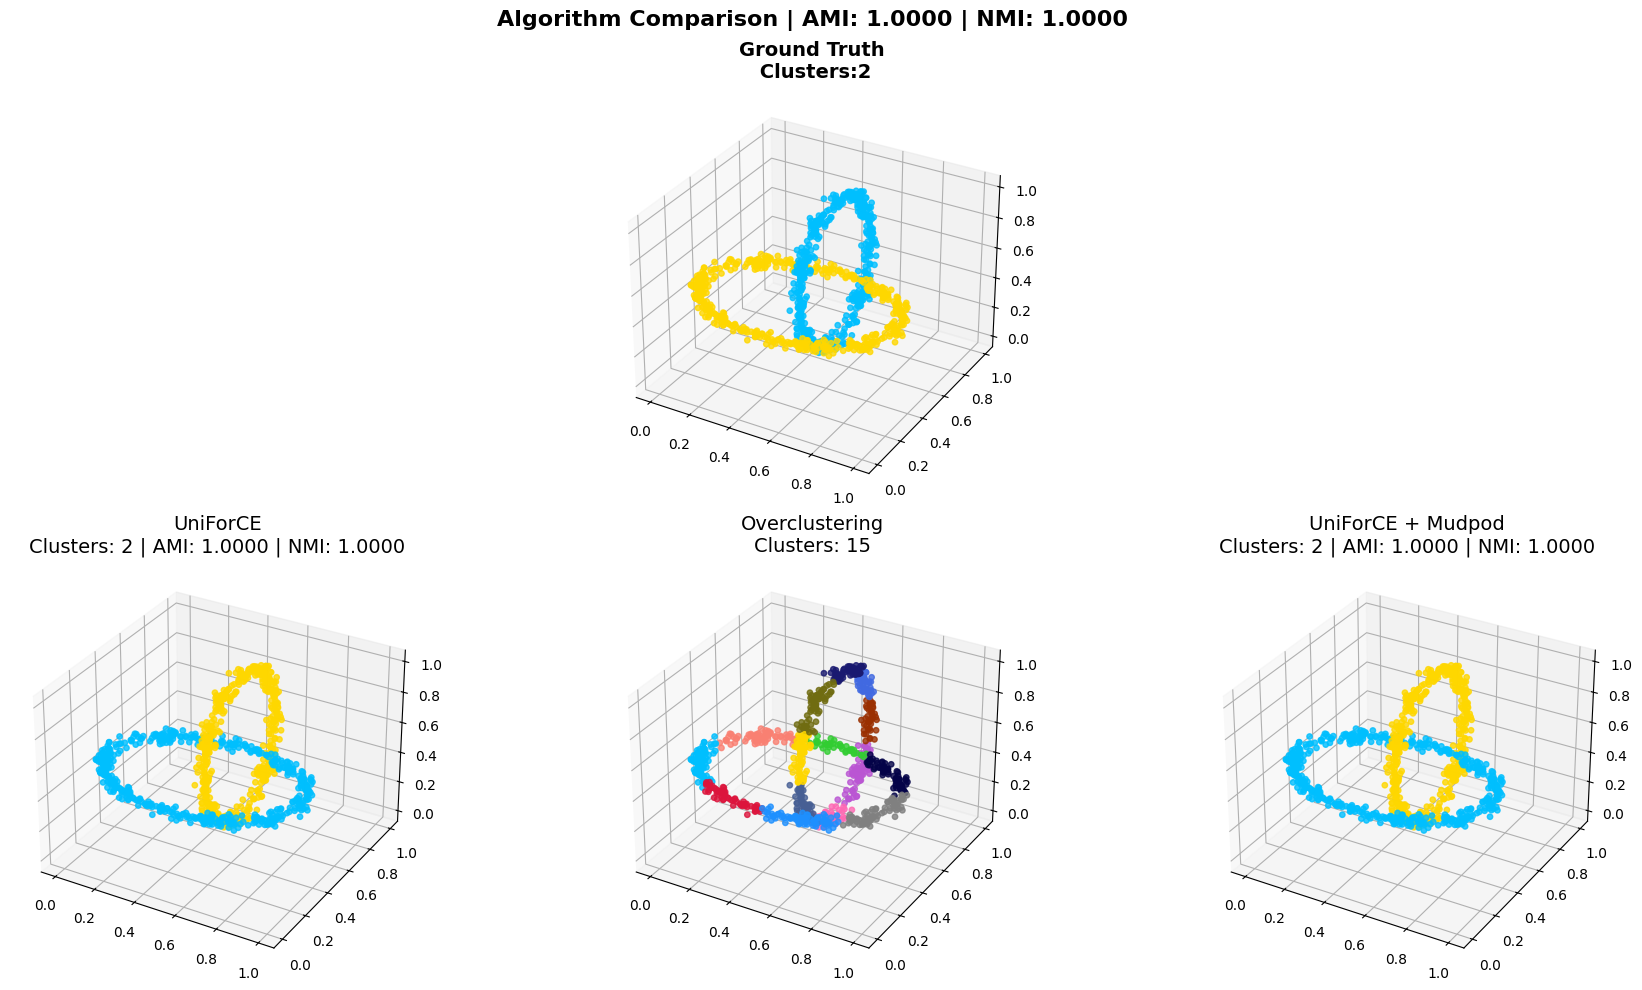

In [62]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np

# setting colours
color_list = list(mcolors.CSS4_COLORS.keys()) + list(mcolors.XKCD_COLORS.keys())
np.random.seed(42) 
np.random.shuffle(color_list)
color_list = ['gold', 'deepskyblue', 'mediumorchid', 'crimson', 'limegreen', 'hotpink', 'royalblue', 'salmon'] + color_list

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 6) 

# 1. ground truth 
ax_gt = fig.add_subplot(gs[0, 2:4], projection='3d')
ax_gt.scatter(data[:, 0], data[:, 1], data[:, 2], c=[color_list[l % len(color_list)] for l in labels], s=15, alpha=0.8)
ax_gt.set_title(f"Ground Truth\n Clusters:{len(np.unique(labels))}", fontsize=14, fontweight='bold')
# ax_gt.axis('off')

# 2. UniForCE 
ax_uf = fig.add_subplot(gs[1, 0:2], projection='3d')
ax_uf.scatter(data[:, 0], data[:, 1], data[:, 2], c=[color_list[l % len(color_list)] for l in uniforce_result.labels], s=15, alpha=0.8)
ax_uf.set_title(f"UniForCE\nClusters: {uniforce_result.n_clusters} | AMI: {ami_uniforce:.4f} | NMI: {nmi_uniforce:.4f}", fontsize=14)
# ax_uf.axis('off')

# 3. overclustering 
ax_over = fig.add_subplot(gs[1, 2:4], projection='3d')
ax_over.scatter(data[:, 0], data[:, 1], data[:, 2], c=[color_list[l % len(color_list)] for l in overClustering_labels], s=15, alpha=0.8)
ax_over.set_title(f"Overclustering\nClusters: {len(np.unique(overClustering_labels))}", fontsize=14)
# ax_over.axis('off')

# 4. SMCUT
ax_mud = fig.add_subplot(gs[1, 4:6], projection='3d')
ax_mud.scatter(data[:, 0], data[:, 1], data[:, 2], c=[color_list[l % len(color_list)] for l in uniforce_mudpod_result.labels], s=15, alpha=0.8)
ax_mud.set_title(f"UniForCE + Mudpod\nClusters: {uniforce_mudpod_result.n_clusters} | AMI: {ami_uniforce_mudpod:.4f} | NMI: {nmi_uniforce_mudpod:.4f}", fontsize=14)
# ax_mud.axis('off')

fig.suptitle(f"Algorithm Comparison | AMI: {algo_comparison_ami:.4f} | NMI: {algo_comparison_nmi:.4f}", fontsize=16, fontweight='bold')

plt.tight_layout()

# saving fig (ground truth, UniForCE, overclustering, mudpod)
filename = f"{dataset_name}_{alpha}_{n_subclusters}_3D.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()